# Mean Field model 

This notebook summarises the coding done for mean field model analysis and the comparison of the simulation with the mean field results. 

In this notebook we will be looking at both the homogeneous and heterogeneous mean field model (HMF). We will analyse some of its results and then compare the simulation with the HMF. 

## Taking from the notes of Mean Field solution
#### Rate equation and steady state solution

Finally, we write the differential equation for the state $p(t)$.  
If agents process new clauses at a rate $r$, and each clause contains 2 variables, variables are tested for flips at a rate $2r$.

The rate of change of the fraction of ones is the flux of variables flipping $0 \to 1$ minus the flux of variables flipping $1 \to 0$:  
$$
\frac{dp}{dt}=2r[(1-p)\ . \Pr(Z>0) - p\ . \Pr(Z<0)]
$$
##### The Steady-State Condition

From the single-bit rate equation we just formulated, the system reaches steady state when $\frac{dp}{dt} = 0$:  
$$(1−p^∗)\Pr⁡(Z>0)=p^∗\Pr⁡(Z<0)$$

Here, we use the Poisson variables $Y \sim \text{Poisson}(\alpha)$ and $X_1 \sim \text{Poisson}(\alpha p^*)$.  
We can solve for the equilibrium fraction of ones, $p^*$:  

$$
p^*=\frac{\Pr(Z>0)}{\Pr(Z>0)+\Pr(Z<0)}
$$


How do we calculate the steady state ($p^*$)?
We find the probability distribution of $Z$.

Note, $Z=Y-X_1$, where $Y$ is a poisson distributed random variable with mean = $\alpha$ and $X_1$ is another poisson distributed random variable with mean $\alpha p$.
I searched online and found that the difference of two Poisson distributed random variables are distributed by a distribution known as Skellam distribution. 

So, we can evaluate the $Pr(Z>0)$, by calling the skellam distributed variable. We can also just user Poisson function, keeping it in terms of $\Pr(Y>X_1)$.

In the following code block, we define dpdt and find the root of the equation, by using `root_scalar` function of scipy.

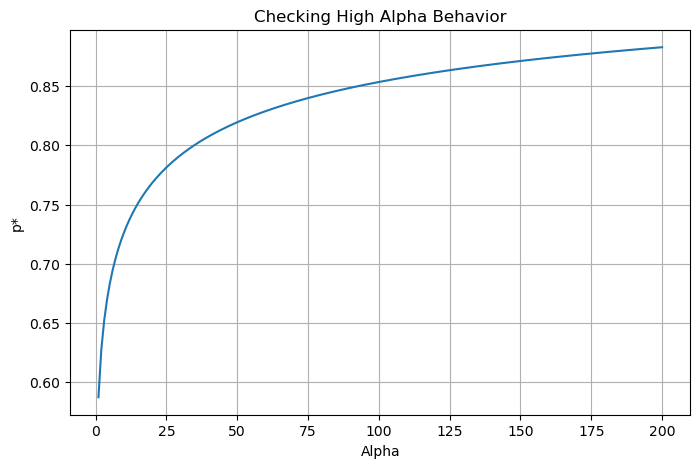

In [ ]:
import numpy as np
from scipy.stats import poisson
import matplotlib.pyplot as plt
from scipy.optimize import root_scalar

def prob_Y_gt_X1(p, alpha):
    # Using scipy.stats.poisson 
    k = np.arange(int(alpha*3 + 100))
    # pmf array for X1 ~ Poisson(alpha * p)
    pmf_X1 = poisson.pmf(k, alpha * p)
    # P(Y > k) = 1 - P(Y <= k) where Y ~ Poisson(alpha)
    # sf(k) = 1 - cdf(k)
    prob_Y_gt_k = poisson.sf(k, alpha, loc=1) 
    return np.sum(pmf_X1 * prob_Y_gt_k)

def prob_X1_gt_Y(p, alpha):
    k = np.arange(int(alpha*3 + 100))
    pmf_Y = poisson.pmf(k, alpha)
    prob_X1_gt_k = poisson.sf(k, alpha * p, loc=1)
    return np.sum(pmf_Y * prob_X1_gt_k)

def dp_dt_eq(p, alpha):
    return (1 - p) * prob_Y_gt_X1(p, alpha) - p * prob_X1_gt_Y(p, alpha)

alphas = np.linspace(1, 200, 200)
p_stars = []

for a in alphas:
    try:
        sol = root_scalar(dp_dt_eq, args=(a,), bracket=[0.01, 0.999], method='brentq')
        p_stars.append(sol.root)
    except Exception as e:
        print(f"Failed at alpha={a}: {e}")
        p_stars.append(np.nan)

p_stars = np.array(p_stars)

plt.figure(figsize=(8,5))
plt.plot(alphas, p_stars)
plt.xlabel("Alpha")
plt.ylabel("p*")
plt.title("Checking High Alpha Behavior")
plt.grid()
#plt.savefig("high_alpha.png")
#plt.close()
plt.show()

In [7]:
k = np.arange(int(alphas[10]*3 + 100))
k,alphas[10]

(array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
         13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
         26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
         39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
         52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
         65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
         78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
         91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
        104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
        117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
        130, 131, 132]),
 np.float64(11.0))

In [8]:
from scipy.stats import skellam
alphas = np.linspace(1, 200, 200)
p_stars = []

for a in alphas:
    try:
        prob_z_gt_0 = 1.0 - skellam.cdf(0, alpha, alpha * p)
        prob_z_lt_0 = skellam.cdf(-1, alpha, alpha * p)
    except Exception as e:
        print(f"Failed at alpha={a}: {e}")
        p_stars.append(np.nan)


Failed at alpha=1.0: name 'alpha' is not defined
Failed at alpha=2.0: name 'alpha' is not defined
Failed at alpha=3.0: name 'alpha' is not defined
Failed at alpha=4.0: name 'alpha' is not defined
Failed at alpha=5.0: name 'alpha' is not defined
Failed at alpha=6.0: name 'alpha' is not defined
Failed at alpha=7.0: name 'alpha' is not defined
Failed at alpha=8.0: name 'alpha' is not defined
Failed at alpha=9.0: name 'alpha' is not defined
Failed at alpha=10.0: name 'alpha' is not defined
Failed at alpha=11.0: name 'alpha' is not defined
Failed at alpha=12.0: name 'alpha' is not defined
Failed at alpha=13.0: name 'alpha' is not defined
Failed at alpha=14.0: name 'alpha' is not defined
Failed at alpha=15.0: name 'alpha' is not defined
Failed at alpha=16.0: name 'alpha' is not defined
Failed at alpha=17.0: name 'alpha' is not defined
Failed at alpha=18.0: name 'alpha' is not defined
Failed at alpha=19.0: name 'alpha' is not defined
Failed at alpha=20.0: name 'alpha' is not defined
Failed at

In [17]:
alpha=alphas[1]
p=0.4
prob_z_gt_0 = 1.0 - skellam.cdf(0, alpha, alpha * p)
prob_z_lt_0 = 1.0 - skellam.cdf(-1, alpha, alpha * p)
Pstar=prob_z_gt_0/(prob_z_gt_0+prob_z_lt_0)
Pstar

np.float64(0.43238323656588007)

## Comparing simulation violations with the violations obtained from the mean field model

Once we know the attractor of the $p$ dynamics, we can evaluate the number of violations.

#### Violation Count

Violation count is given by:

$$
V=1-p^*+\frac{{p^*}^2}{2}
$$

Total violation count is thus given by $M \times V$

In the next code block, we first evaluate $p^*$ using the method explained above. Then we find $V$ and the total violations. We can then compare it with the model.

For the comparison, we perform 1 simulation (you can edit this parameter) for each value of $\alpha$ for a 50 node erdos reni network.

Run the following cell to generate the comparison. Note it will take a few minutes (~20) to generate the result. 

Running ensemble on ER Random Networks (N=50, runs=1)...
Alpha  1.0 | Theory: 11.7 | Sim (ER): 8.3
Alpha  2.0 | Theory: 22.8 | Sim (ER): 18.4
Alpha  5.0 | Theory: 55.0 | Sim (ER): 43.7
Alpha 10.0 | Theory: 107.5 | Sim (ER): 90.0
Alpha 25.0 | Theory: 262.0 | Sim (ER): 245.7
Alpha 50.0 | Theory: 516.3 | Sim (ER): 495.9
Alpha 100.0 | Theory: 1021.5 | Sim (ER): 1005.4
Simulation Complete. Plotting...


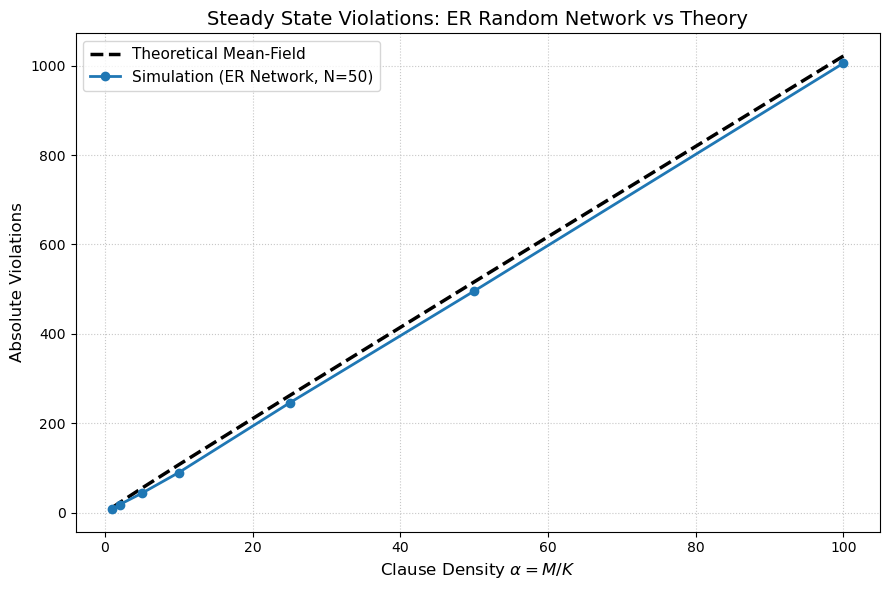

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson
from scipy.optimize import root_scalar
import sys,os

sys.path.append(os.path.abspath(os.path.join('..')))
from model_2026_04_26 import ProblemSolvingModel, Person
# ==========================================
# 1. Theoretical Poisson Equilibrium
# ==========================================
def prob_Y_gt_X1(p, alpha):
    k = np.arange(int(alpha * 3 + 100))
    pmf_X1 = poisson.pmf(k, alpha * p)
    prob_Y_gt_k = poisson.sf(k, alpha, loc=1)
    return np.sum(pmf_X1 * prob_Y_gt_k)

def prob_X1_gt_Y(p, alpha):
    k = np.arange(int(alpha * 3 + 100))
    pmf_Y = poisson.pmf(k, alpha)
    prob_X1_gt_k = poisson.sf(k, alpha * p, loc=1)
    return np.sum(pmf_Y * prob_X1_gt_k)

def dp_dt_eq(p, alpha):
    return (1 - p) * prob_Y_gt_X1(p, alpha) - p * prob_X1_gt_Y(p, alpha)

def get_theoretical_V_absolute(alpha, K_vars):
    try:
        sol = root_scalar(dp_dt_eq, args=(alpha,), bracket=[0.01, 0.999], method='brentq')
        p_star = sol.root
        v_frac = 1 - p_star + (p_star**2) / 2
        M_clauses = alpha * K_vars
        return M_clauses * v_frac
    except Exception:
        return np.nan

# ==========================================
# 2. Simulation & Ensemble Parameters
# ==========================================
alphas = [1.0,2.0, 5.0, 10.0,25.0, 50.0, 100.0]
K_vars = 20       # Binary variables
N = 50            # Reduced agents to save computation time
steps = 250       # Ticks to reach steady state
num_runs = 1     # Average over 20 runs to eliminate the noise you saw in image 64

# ER Network parameters
connect_prob = 0.2  # ~10 edges per node on average for N=50

sim_V_abs = []
theo_V_abs = []

print(f"Running ensemble on ER Random Networks (N={N}, runs={num_runs})...")

for alpha in alphas:
    M_clauses = int(alpha * K_vars)
    theo_V_abs.append(get_theoretical_V_absolute(alpha, K_vars))
    
    alpha_final_violations = []
    
    for run in range(num_runs):
        model = ProblemSolvingModel(
            N=N, K=K_vars, alpha=alpha,
            setup_source="generate",          # Use internal generator
            type_network="Random",            # Trigger setup_random_network
            connect_prob=connect_prob,        # ER edge probability
            kb_fraction=0.75, 
            seed=run
        )
        
        # Run to steady-state
        for t in range(steps):
            model.step()
            # Proactive Reflection Patch (to mirror your previous setup)
            for a in model.agents:
                for c in a.kb:
                    a.local_update_around(c)
                    
        # Extract mean final violations across all nodes in the ER graph
        v_mean = np.mean([a.true_violations for a in model.agents])
        alpha_final_violations.append(v_mean)
        
    mean_sim_V = np.mean(alpha_final_violations)
    sim_V_abs.append(mean_sim_V)
    
    print(f"Alpha {alpha:4.1f} | Theory: {theo_V_abs[-1]:.1f} | Sim (ER): {sim_V_abs[-1]:.1f}")

# ==========================================
# 3. Plotting Results
# ==========================================
print("Simulation Complete. Plotting...")

plt.figure(figsize=(9, 6))

plt.plot(alphas, theo_V_abs, 'k--', label="Theoretical Mean-Field", linewidth=2.5)
plt.plot(alphas, sim_V_abs, 'o-', label=f"Simulation (ER Network, N={N})", color='#1f77b4', linewidth=2)

plt.xlabel(r"Clause Density $\alpha = M/K$", fontsize=12)
plt.ylabel(r"Absolute Violations", fontsize=12)
plt.title("Steady State Violations: ER Random Network vs Theory", fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.savefig("theory_vs_er_network.png", dpi=300)
plt.show()

## Heterogeneous Mean Field Model

the probability that a randomly sampled partner variable is in state 1 is no longer the simple node average $p(t)$, but the degree-weighted average $\Theta(t)$:
$$\Theta(t) = \sum_{k} q(k) p_k(t) = \frac{1}{\langle k \rangle} \sum_{k=1}^{k_{max}} k P(k) p_k(t)$$
This, adds the degree dependence in the probability itself. 

$$ \frac{dp_k}{dt} = R_k \Big[ (1 - p_k) \Pr(Z (\Theta) > 0) - p_k \Pr(Z(\Theta) < 0) \Big] \tag{4}$$
Once more because the interaction rate $R_k = 2(r_{obs} + \lambda \frac{k}{\langle k \rangle})$ simply factors out, the equilibrium fraction of ones for class $k$ becomes:

$$p_k^* = \frac{Pr(Z(\Theta^*) > 0)}{Pr(Z(\Theta^*) > 0) + Pr(Z(\Theta^*) < 0)}$$


Let us first solve the ODEs using Scipy for a particular degree distribution

Universal Steady-State p*: 0.6892


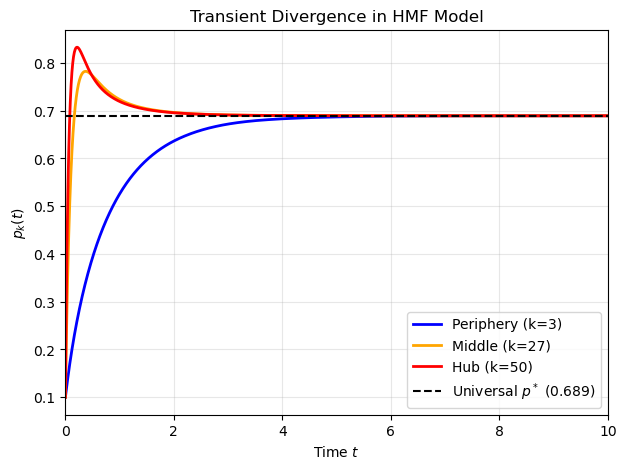

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.stats import skellam
from scipy.optimize import root_scalar

# ==========================================
# 1. Network and Model Parameters
# ==========================================
alpha = 3.0          # Clause density M/K
lambda_param = 1.0   # Interaction scaler
r_obs = 0.1          # Base observation rate
k_min, k_max = 3, 50 # Degree boundaries
gamma_exp = 2.5      # Power-law exponent for Scale-Free network

# Generate Scale-Free Degree Distribution P(k) ~ k^(-gamma)
k_vec = np.arange(k_min, k_max + 1)
P_k_raw = k_vec**(-gamma_exp)
P_k = P_k_raw / np.sum(P_k_raw) # Normalize
k_mean = np.sum(k_vec * P_k)

# Interaction rates R_k
R_k = 2 * (r_obs + lambda_param * (k_vec / k_mean))

# ==========================================
# 2. Probability Functions (Skellam)
# ==========================================
def get_flip_probs(theta):
    # Z = Y - X_1 ~ Skellam(mu1=alpha, mu2=alpha*theta)
    # Pr(Z > 0) = 1 - CDF(0)
    # Pr(Z < 0) = CDF(-1)
    prob_z_gt_0 = 1.0 - skellam.cdf(0, alpha, alpha * theta)
    prob_z_lt_0 = skellam.cdf(-1, alpha, alpha * theta)
    
    alpha_theta = prob_z_gt_0
    beta_theta = prob_z_gt_0 + prob_z_lt_0
    return alpha_theta, beta_theta

# ==========================================
# 3. The Dynamical System (ODE)
# ==========================================

def mean_field_odes(t, p_vec):
    # Calculate the edge-weighted probability Theta(t)
    theta = np.sum(k_vec * P_k * p_vec) / k_mean
    
    alpha_theta, beta_theta = get_flip_probs(theta)
    
    # dp_k / dt
    dpdt = R_k * (alpha_theta - p_vec * beta_theta)
    return dpdt

# Initial conditions (e.g., uniformly random initialization)
p0 = np.ones(len(k_vec)) * 0.1 
t_span = (0, 15)
t_eval = np.linspace(0, 15, 3000)

# Integrate
sol = solve_ivp(mean_field_odes, t_span, p0, t_eval=t_eval, method='LSODA')

# ==========================================
# 4. Steady-State and Jacobian Analysis
# ==========================================
# The universal steady-state p* solves: alpha(p*) - p* beta(p*) = 0
def steady_state_eq(p):
    a, b = get_flip_probs(p)
    return a - p * b

res = root_scalar(steady_state_eq, bracket=[0.01, 0.99])
p_star = res.root

# ==========================================
# 5. Visualization
# ==========================================
plt.figure(figsize=(7, 5))

# Plot A: Transient Dynamics
plt.subplot(1, 1, 1)
plt.plot(sol.t, sol.y[0, :], label=f'Periphery (k={k_vec[0]})', color='blue', linewidth=2)
plt.plot(sol.t, sol.y[len(k_vec)//2, :], label=f'Middle (k={k_vec[len(k_vec)//2]})', color='orange', linewidth=2)
plt.plot(sol.t, sol.y[-1, :], label=f'Hub (k={k_vec[-1]})', color='red', linewidth=2)
plt.axhline(p_star, color='black', linestyle='--', label=f'Universal $p^*$ ({p_star:.3f})')
plt.title('Transient Divergence in HMF Model')
plt.xlabel('Time $t$')
plt.ylabel('$p_k(t)$')
plt.xlim(0, 10) # Zoom in on early time to see the fanning out
plt.legend()
plt.grid(True, alpha=0.3)

print(f"Universal Steady-State p*: {p_star:.4f}")


Universal Steady-State p*: 0.6892


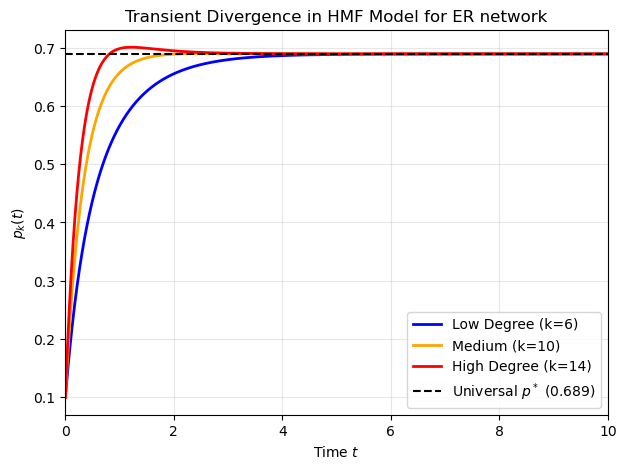

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.stats import skellam
from scipy.optimize import root_scalar


# ==========================================
# 1. Network and Model Parameters (Erdős-Rényi)
# ==========================================
alpha = 3.0          # Clause density M/K
lambda_param = 1.0   # Interaction scaler
r_obs = 0.1          # Base observation rate

k_mean_target = 10   # Average degree <k> for the ER network
k_min, k_max = 1, 30 # Range around the mean (Poisson tails off quickly)

k_vec = np.arange(k_min, k_max + 1)

# Generate Erdős-Rényi Degree Distribution (Poisson)
P_k_raw = poisson.pmf(k_vec, k_mean_target)
P_k = P_k_raw / np.sum(P_k_raw) # Normalize the truncated distribution
k_mean = np.sum(k_vec * P_k)    # Exact mean of the truncated array

# Interaction rates R_k
R_k = 2 * (r_obs + lambda_param * (k_vec / k_mean))

# ==========================================
# 2. Probability Functions (Skellam)
# ==========================================
def get_flip_probs(theta):
    # Z = Y - X_1 ~ Skellam(mu1=alpha, mu2=alpha*theta)
    # Pr(Z > 0) = 1 - CDF(0)
    # Pr(Z < 0) = CDF(-1)
    prob_z_gt_0 = 1.0 - skellam.cdf(0, alpha, alpha * theta)
    prob_z_lt_0 = skellam.cdf(-1, alpha, alpha * theta)
    
    alpha_theta = prob_z_gt_0
    beta_theta = prob_z_gt_0 + prob_z_lt_0
    return alpha_theta, beta_theta

# ==========================================
# 3. The Dynamical System (ODE)
# ==========================================

def mean_field_odes(t, p_vec):
    # Calculate the edge-weighted probability Theta(t)
    theta = np.sum(k_vec * P_k * p_vec) / k_mean
    
    alpha_theta, beta_theta = get_flip_probs(theta)
    
    # dp_k / dt
    dpdt = R_k * (alpha_theta - p_vec * beta_theta)
    return dpdt

# Initial conditions (e.g., uniformly random initialization)
p0 = np.ones(len(k_vec)) * 0.1 
t_span = (0, 15)
t_eval = np.linspace(0, 15, 3000)

# Integrate
sol = solve_ivp(mean_field_odes, t_span, p0, t_eval=t_eval, method='LSODA')

# ==========================================
# 4. Steady-State and Jacobian Analysis
# ==========================================
# The universal steady-state p* solves: alpha(p*) - p* beta(p*) = 0
def steady_state_eq(p):
    a, b = get_flip_probs(p)
    return a - p * b

res = root_scalar(steady_state_eq, bracket=[0.01, 0.99])
p_star = res.root

# ==========================================
# 5. Visualization
# ==========================================
plt.figure(figsize=(7, 5))
# Plot A: Transient Dynamics
# Find the indices for the realistic bulk of the ER network
idx_low = np.where(k_vec == 6)[0][0]
idx_mean = np.where(k_vec == 10)[0][0]
idx_high = np.where(k_vec == 14)[0][0]

plt.subplot(1, 1, 1)
plt.plot(sol.t, sol.y[idx_low, :], label=f'Low Degree (k=6)', color='blue', linewidth=2)
plt.plot(sol.t, sol.y[idx_mean, :], label=f'Medium (k=10)', color='orange', linewidth=2)
plt.plot(sol.t, sol.y[idx_high, :], label=f'High Degree (k=14)', color='red', linewidth=2)
plt.axhline(p_star, color='black', linestyle='--', label=f'Universal $p^*$ ({p_star:.3f})')
#plt.axhline(p_star, color='black', linestyle='--', label=f'Universal $p^*$ ({p_star:.3f})')
plt.title('Transient Divergence in HMF Model for ER network')
plt.xlabel('Time $t$')
plt.ylabel('$p_k(t)$')
plt.xlim(0, 10) # Zoom in on early time to see the fanning out
plt.legend()
plt.grid(True, alpha=0.3)


print(f"Universal Steady-State p*: {p_star:.4f}")


### Comparison of the model 

Let us compare the  ODE solution with the simulations. Starting with one Barabasi Albert network

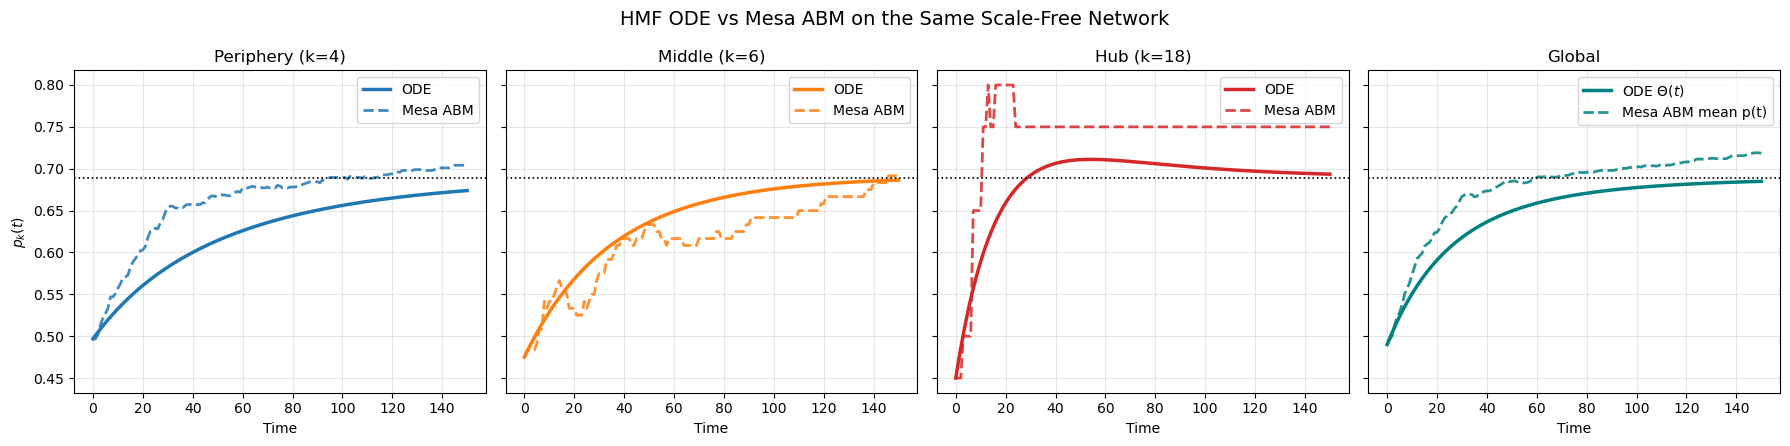

Unique degrees: [4, 5, 6, 7, 8, 9, 10, 11, 16, 17, 18]
<k> = 5.9200
Steady-state p* = 0.689213
Initial ODE condition taken from ABM: shape = (11,)


In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.stats import skellam
from scipy.optimize import root_scalar
import sys,os

sys.path.append(os.path.abspath(os.path.join('..')))
from model_2026_04_26 import ProblemSolvingModel, Person


# ============================================================
# 1. Parameters
# ============================================================
N = 100 # NODES
m = 2
K = 20
alpha = 3.0
steps = 150
seed = 7

r_obs = 0.1
lambda_param = 1.0

obsprob = 0.1 # same as r_pbs
kb_fraction = 1
localobsfraction = 1



# ============================================================
# 2. HMF helper functions
# ============================================================
def get_flip_probs(theta, alpha):
    theta = np.clip(theta, 1e-12, 1 - 1e-12)

    # Your derivation:
    # Y = A1 + X0 ~ Poisson(alpha)
    # X1 ~ Poisson(alpha * theta)
    # Z = Y - X1 ~ Skellam(alpha, alpha*theta)

    prob_z_gt_0 = 1.0 - skellam.cdf(0, alpha, alpha * theta)
    prob_z_lt_0 = skellam.cdf(-1, alpha, alpha * theta)

    a_Theta = prob_z_gt_0
    b_Theta = prob_z_gt_0 + prob_z_lt_0
    return a_Theta, b_Theta


def build_hmf_system(k_vec, P_k, alpha, r_obs, lambda_param,c_t):
    k_mean = np.sum(k_vec * P_k)
#    c_t=0.01
    R_k = c_t * 2 * (r_obs + lambda_param * (k_vec / k_mean))

    def mean_field_odes(t, p_vec):
        theta = np.sum(k_vec * P_k * p_vec) / k_mean
        a_Theta, b_Theta = get_flip_probs(theta, alpha)
        dpdt = R_k * (a_Theta - p_vec * b_Theta)
        return dpdt

    def steady_state_eq(p):
        a, b = get_flip_probs(p, alpha)
        return a - p * b

    return mean_field_odes, steady_state_eq, R_k, k_mean


# ============================================================
# 3. Utilities to extract p_k(t) from the Mesa model
# ============================================================
def get_degree_classes_from_graph(G):
    degrees = dict(G.degree())
    unique_degrees = sorted(set(degrees.values()))
    return degrees, unique_degrees


def get_pk_from_model(model, degrees, unique_degrees):
    """
    p_k(t) = average fraction of 1s across agents whose node degree is k
    """
    pk = []
    for k in unique_degrees:
        nodes_k = [n for n, d in degrees.items() if d == k]
        if len(nodes_k) == 0:
            pk.append(np.nan)
            continue

        vals = []
        for n in nodes_k:
            agent = model.agents[n]
            vals.append(np.mean(agent.x))
        pk.append(np.mean(vals))
    return np.array(pk)


def get_global_p_from_model(model):
    return np.mean([np.mean(a.x) for a in model.agents])


# ============================================================
# 4. One shared network
# ============================================================
G_BA = nx.barabasi_albert_graph(N, m, seed=seed)

# Keep self-loop convention from the existing scripts
# for i in range(N):
#     G_BA.add_edge(i, i)

degrees, unique_degrees = get_degree_classes_from_graph(G_BA)
k_vec = np.array(unique_degrees)

# empirical degree distribution P(k)
degree_counts = np.array([sum(1 for d in degrees.values() if d == k) for k in k_vec], dtype=float)
P_k = degree_counts / degree_counts.sum()


# ============================================================
# 5. Run Mesa ABM on the shared network
# ============================================================
hist_pk_abm = []
hist_global_abm = []

model = ProblemSolvingModel(
    N=N,
    K=K,
    alpha=alpha,
    setup_source="graph",
    input_graph=G_BA,
    kb_fraction=kb_fraction,
    local_obs_fraction=localobsfraction,
    obs_prob=obsprob,
    seed=seed
)

# Initial condition for the ODE from the ABM itself
p0_ode = get_pk_from_model(model, degrees, unique_degrees)
hist_pk_abm.append(p0_ode.copy())
hist_global_abm.append(get_global_p_from_model(model))

for t in range(steps):
    model.step()

    # Optional reflection patch, matching your existing workflow
    for a in model.agents:
        for c in a.kb:
            a.local_update_around(c)

    model.calc_performances()

    hist_pk_abm.append(get_pk_from_model(model, degrees, unique_degrees))
    hist_global_abm.append(get_global_p_from_model(model))

hist_pk_abm = np.array(hist_pk_abm)          # shape: (steps+1, num_k_classes)
hist_global_abm = np.array(hist_global_abm)  # shape: (steps+1,)


def estimate_early_slope(y, t0=0, t1=10):
    x = np.arange(t0, t1 + 1)
    coeff = np.polyfit(x, y[t0:t1 + 1], 1)
    return coeff[0]

abm_global = np.array(hist_global_abm)

# raw HMF slope at t=0 using the same initial condition
R_k_base = 2 * (r_obs + lambda_param * (k_vec / k_mean))

c_time=0.01
R_k = c_time * R_k_base

mean_field_odes, steady_state_eq, R_k, k_mean = build_hmf_system(
    k_vec=k_vec,
    P_k=P_k,
    alpha=alpha,
    r_obs=r_obs,
    lambda_param=lambda_param,
    c_t=c_time
)
# ============================================================
# 6. Solve ODE using same initial p_k(0)
# ============================================================
t_eval = np.arange(steps + 1)

sol = solve_ivp(
    mean_field_odes,
    (0, steps),
    p0_ode,
    t_eval=t_eval,
    method="LSODA",
    rtol=1e-7,
    atol=1e-9
)

hist_pk_ode = sol.y.T

hist_global_ode = np.array([
    np.sum(k_vec * P_k * hist_pk_ode[t]) / k_mean
    for t in range(len(t_eval))
])

res = root_scalar(steady_state_eq, bracket=[0.01, 0.99])
p_star = res.root


# ============================================================
# 7. Pick representative degree classes
# ============================================================
k_periph = min(unique_degrees)
k_hub = max(unique_degrees)
k_mid = unique_degrees[np.argmin(np.abs(np.array(unique_degrees) - k_mean))]

plot_ks = [k_periph, k_mid, k_hub]
plot_titles = [
    f"Periphery (k={k_periph})",
    f"Middle (k={k_mid})",
    f"Hub (k={k_hub})"
]
plot_colors = ["tab:blue", "tab:orange", "tab:red"]

plot_indices = [unique_degrees.index(k) for k in plot_ks]


# ============================================================
# 8. Plot comparison
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5), sharey=True)

for i, (k_idx, title, color) in enumerate(zip(plot_indices, plot_titles, plot_colors)):
    ax = axes[i]
    ax.plot(t_eval, hist_pk_ode[:, k_idx], color=color, lw=2.5, label="ODE")
    ax.plot(t_eval, hist_pk_abm[:, k_idx], color=color, lw=2.0, ls="--", alpha=0.85, label="Mesa ABM")
    ax.axhline(p_star, color="black", ls=":", lw=1.2)
    ax.set_title(title)
    ax.set_xlabel("Time")
    if i == 0:
        ax.set_ylabel(r"$p_k(t)$")
    ax.grid(alpha=0.3)
    ax.legend()

# Global panel
ax = axes[3]
ax.plot(t_eval, hist_global_ode, color="teal", lw=2.5, label=r"ODE $\Theta(t)$")
ax.plot(t_eval, hist_global_abm, color="teal", lw=2.0, ls="--", alpha=0.85, label="Mesa ABM mean p(t)")
ax.axhline(p_star, color="black", ls=":", lw=1.2)
ax.set_title("Global")
ax.set_xlabel("Time")
ax.grid(alpha=0.3)
ax.legend()

fig.suptitle("HMF ODE vs Mesa ABM on the Same Scale-Free Network", fontsize=14)
plt.tight_layout()
plt.show()


# ============================================================
# 9. Print useful diagnostics
# ============================================================
print(f"Unique degrees: {unique_degrees}")
print(f"<k> = {k_mean:.4f}")
print(f"Steady-state p* = {p_star:.6f}")
print(f"Initial ODE condition taken from ABM: shape = {p0_ode.shape}")

We run the simulation num_runs=5 times

Run 1/5 done 
Run 2/5 done 
Run 3/5 done 
Run 4/5 done 
Run 5/5 done 


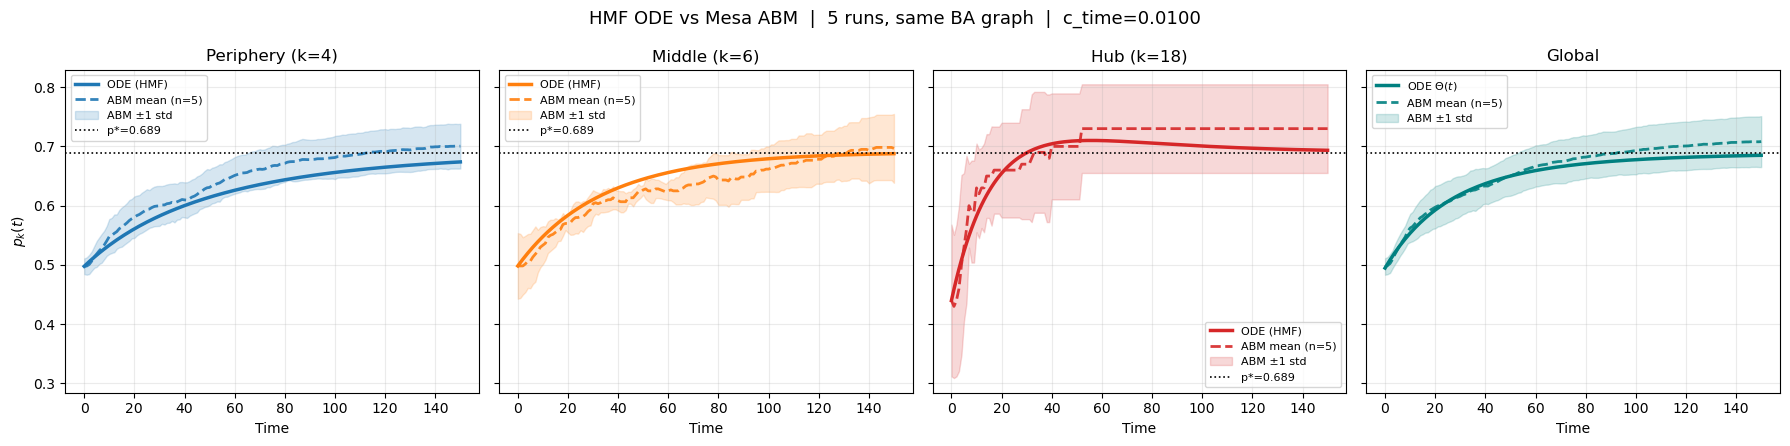


Unique degrees : [4, 5, 6, 7, 8, 9, 10, 11, 16, 17, 18]
<k>            : 5.9200
p*             : 0.689213
Mean c_time    : 0.01000


In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.stats import skellam
from scipy.optimize import root_scalar
import sys, os

sys.path.append(os.path.abspath(os.path.join('..')))
from model_2026_04_26 import ProblemSolvingModel

# ============================================================
# 1. Parameters
# ============================================================
N      = 100
m      = 2
K      = 20
alpha  = 3.0
steps  = 150
seed   = 7
num_runs = 5                # number of ABM runs to average

r_obs        = 0.1
lambda_param = 1.0
obsprob      = 0.1
kb_fraction      = 1
localobsfraction = 1


# ============================================================
# 4. Shared network — built once, reused in every run       
# ============================================================
G_BA = nx.barabasi_albert_graph(N, m, seed=seed)
# for i in range(N):
#     G_BA.add_edge(i, i)                         # self-loop convention

degrees, unique_degrees = dict(G_BA.degree()), sorted(set(dict(G_BA.degree()).values()))
degrees = dict(G_BA.degree())
k_vec   = np.array(unique_degrees)

degree_counts = np.array(
    [sum(1 for d in degrees.values() if d == k) for k in k_vec], dtype=float)
P_k    = degree_counts / degree_counts.sum()
k_mean_raw = np.sum(k_vec * P_k)

R_k_base = 2 * (r_obs + lambda_param * (k_vec / k_mean_raw))


# ============================================================
# 5. Ensemble of ABM runs                                   ← NEW
# ============================================================
all_pk_abm     = []   # list of (steps+1, n_k) arrays, one per run
all_global_abm = []   # list of (steps+1,) arrays

for run in range(num_runs):
    run_seed = seed + run * 13     # different seed per run, reproducible

    model = ProblemSolvingModel(
        N=N,
        K=K,
        alpha=alpha,
        setup_source="graph",
        input_graph=G_BA,          # same graph every run ← key
        kb_fraction=kb_fraction,
        local_obs_fraction=localobsfraction,
        obs_prob=obsprob,
        seed=run_seed
    )

    p0 = get_pk_from_model(model, degrees, unique_degrees)
    pk_hist     = [p0.copy()]
    global_hist = [get_global_p_from_model(model)]

    for t in range(steps):
        model.step()
        for a in model.agents:
            for c in a.kb:
                a.local_update_around(c)
        model.calc_performances()
        pk_hist.append(get_pk_from_model(model, degrees, unique_degrees))
        global_hist.append(get_global_p_from_model(model))

    pk_hist     = np.array(pk_hist)
    global_hist = np.array(global_hist)
    all_pk_abm.append(pk_hist)
    all_global_abm.append(global_hist)

    print(f"Run {run+1}/{num_runs} done ")

# ── ensemble statistics ─────────────────────────────────────── ← NEW
all_pk_abm     = np.array(all_pk_abm)     # (num_runs, steps+1, n_k)
all_global_abm = np.array(all_global_abm) # (num_runs, steps+1)

mean_pk_abm     = np.nanmean(all_pk_abm,     axis=0)  # (steps+1, n_k)
std_pk_abm      = np.nanstd(all_pk_abm,      axis=0)
mean_global_abm = np.mean(all_global_abm,    axis=0)  # (steps+1,)
std_global_abm  = np.std(all_global_abm,     axis=0)


#=============================================================
c_time=0.01

# ============================================================
# 6. Build & solve ODE with calibrated c_time
# ============================================================

# Initial condition = mean p_k(0) across runs            ← NEW
p0_ode = np.nanmean(all_pk_abm[:, 0, :], axis=0)

mean_field_odes, steady_state_eq, R_k, k_mean = build_hmf_system(
    k_vec=k_vec,
    P_k=P_k,
    alpha=alpha,
    r_obs=r_obs,
    lambda_param=lambda_param,
    c_t=c_time
)

t_eval = np.arange(steps + 1)

sol = solve_ivp(
    mean_field_odes,
    (0, steps),
    p0_ode,
    t_eval=t_eval,
    method="LSODA",
    rtol=1e-7,
    atol=1e-9
)

hist_pk_ode   = sol.y.T
hist_global_ode = np.array(
    [np.sum(k_vec * P_k * hist_pk_ode[t]) / k_mean for t in range(len(t_eval))]
)

res    = root_scalar(steady_state_eq, bracket=[0.01, 0.99])
p_star = res.root


# ============================================================
# 7. Pick representative degree classes
# ============================================================
k_periph = min(unique_degrees)
k_hub    = max(unique_degrees)
k_mid    = unique_degrees[np.argmin(np.abs(np.array(unique_degrees) - k_mean))]

plot_ks      = [k_periph, k_mid, k_hub]
plot_titles  = [f"Periphery (k={k_periph})", f"Middle (k={k_mid})", f"Hub (k={k_hub})"]
plot_colors  = ["tab:blue", "tab:orange", "tab:red"]
plot_indices = [unique_degrees.index(k) for k in plot_ks]


# ============================================================
# 8. Plot
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5), sharey=True)

for i, (k_idx, title, color) in enumerate(zip(plot_indices, plot_titles, plot_colors)):
    ax = axes[i]
    # ODE
    ax.plot(t_eval, hist_pk_ode[:, k_idx],
            color=color, lw=2.5, label="ODE (HMF)")
    # ABM mean ± std band                                  ← NEW
    ax.plot(t_eval, mean_pk_abm[:, k_idx],
            color=color, lw=2.0, ls="--", alpha=0.9, label=f"ABM mean (n={num_runs})")
    ax.fill_between(                                       # ← NEW
        t_eval,
        mean_pk_abm[:, k_idx] - std_pk_abm[:, k_idx],
        mean_pk_abm[:, k_idx] + std_pk_abm[:, k_idx],
        color=color, alpha=0.18, label="ABM ±1 std"
    )
    ax.axhline(p_star, color="black", ls=":", lw=1.2, label=f"p*={p_star:.3f}")
    ax.set_title(title)
    ax.set_xlabel("Time")
    if i == 0:
        ax.set_ylabel(r"$p_k(t)$")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)

# Global panel
ax = axes[3]
ax.plot(t_eval, hist_global_ode,
        color="teal", lw=2.5, label=r"ODE $\Theta(t)$")
ax.plot(t_eval, mean_global_abm,
        color="teal", lw=2.0, ls="--", alpha=0.9, label=f"ABM mean (n={num_runs})")
ax.fill_between(                                           # ← NEW
    t_eval,
    mean_global_abm - std_global_abm,
    mean_global_abm + std_global_abm,
    color="teal", alpha=0.18, label="ABM ±1 std"
)
ax.axhline(p_star, color="black", ls=":", lw=1.2)
ax.set_title("Global")
ax.set_xlabel("Time")
ax.grid(alpha=0.25)
ax.legend(fontsize=8)

fig.suptitle(
    f"HMF ODE vs Mesa ABM  |  {num_runs} runs, same BA graph  "
    f"|  c_time={c_time:.4f}",
    fontsize=13
)
plt.tight_layout()
plt.savefig("hmf_ensemble_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


# ============================================================
# 9. Diagnostics
# ============================================================
print(f"\nUnique degrees : {unique_degrees}")
print(f"<k>            : {k_mean:.4f}")
print(f"p*             : {p_star:.6f}")
print(f"Mean c_time    : {c_time:.5f}")

And same BA graph 50 times

Run 1/50 done 
Run 2/50 done 
Run 3/50 done 
Run 4/50 done 
Run 5/50 done 
Run 6/50 done 
Run 7/50 done 
Run 8/50 done 
Run 9/50 done 
Run 10/50 done 
Run 11/50 done 
Run 12/50 done 
Run 13/50 done 
Run 14/50 done 
Run 15/50 done 
Run 16/50 done 
Run 17/50 done 
Run 18/50 done 
Run 19/50 done 
Run 20/50 done 
Run 21/50 done 
Run 22/50 done 
Run 23/50 done 
Run 24/50 done 
Run 25/50 done 
Run 26/50 done 
Run 27/50 done 
Run 28/50 done 
Run 29/50 done 
Run 30/50 done 
Run 31/50 done 
Run 32/50 done 
Run 33/50 done 
Run 34/50 done 
Run 35/50 done 
Run 36/50 done 
Run 37/50 done 
Run 38/50 done 
Run 39/50 done 
Run 40/50 done 
Run 41/50 done 
Run 42/50 done 
Run 43/50 done 
Run 44/50 done 
Run 45/50 done 
Run 46/50 done 
Run 47/50 done 
Run 48/50 done 
Run 49/50 done 
Run 50/50 done 


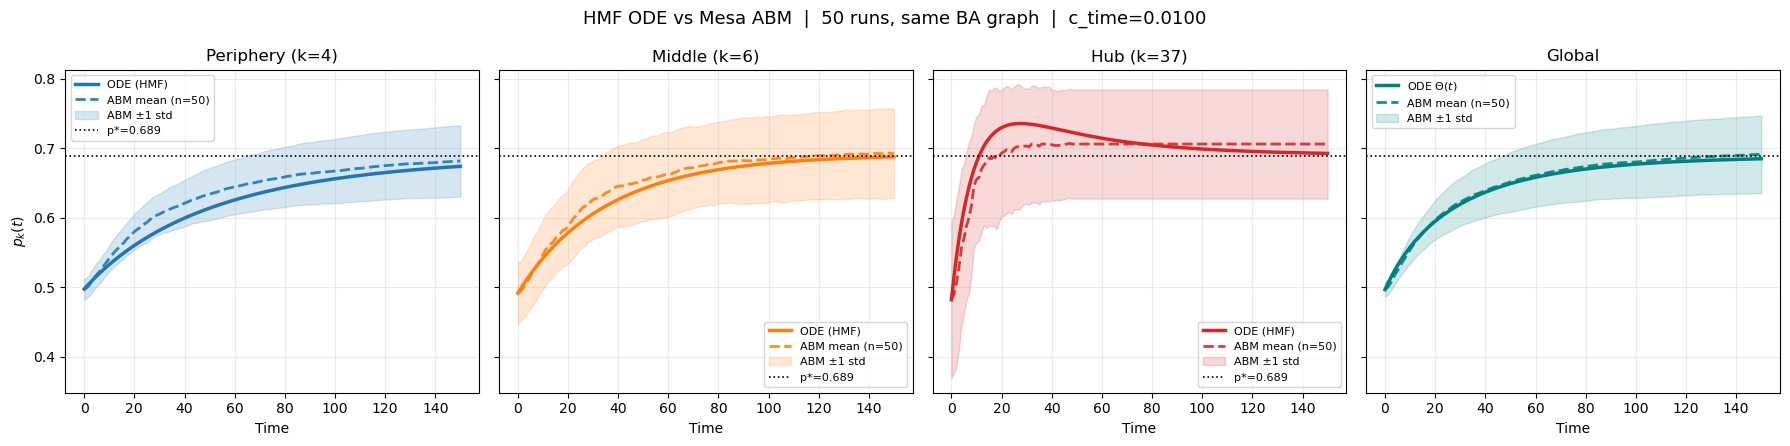


Unique degrees : [4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 37]
<k>            : 5.9200
p*             : 0.689213
Mean c_time    : 0.01000


In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.stats import skellam
from scipy.optimize import root_scalar
import sys, os

sys.path.append(os.path.abspath(os.path.join('..')))
from model_2026_04_26 import ProblemSolvingModel

# ============================================================
# 1. Parameters
# ============================================================
N      = 100
m      = 2
K      = 20
alpha  = 3.0
steps  = 150
seed   = 10
num_runs = 50                # ← NEW: number of ABM runs to average

r_obs        = 0.1
lambda_param = 1.0
obsprob      = 0.1
kb_fraction      = 1
localobsfraction = 1


G_BA = nx.barabasi_albert_graph(N, m, seed=seed)
# for i in range(N):
#     G_BA.add_edge(i, i)                         # self-loop convention

degrees, unique_degrees = dict(G_BA.degree()), sorted(set(dict(G_BA.degree()).values()))
degrees = dict(G_BA.degree())
k_vec   = np.array(unique_degrees)

degree_counts = np.array(
    [sum(1 for d in degrees.values() if d == k) for k in k_vec], dtype=float)
P_k    = degree_counts / degree_counts.sum()
k_mean_raw = np.sum(k_vec * P_k)

R_k_base = 2 * (r_obs + lambda_param * (k_vec / k_mean_raw))


# ============================================================
# 5. Ensemble of ABM runs                                   
# ============================================================
all_pk_abm     = []   # list of (steps+1, n_k) arrays, one per run
all_global_abm = []   # list of (steps+1,) arrays

for run in range(num_runs):
    run_seed = seed + run * 13     # different seed per run, reproducible

    model = ProblemSolvingModel(
        N=N,
        K=K,
        alpha=alpha,
        setup_source="graph",
        input_graph=G_BA,          # same graph every run ← key
        kb_fraction=kb_fraction,
        local_obs_fraction=localobsfraction,
        obs_prob=obsprob,
        seed=run_seed
    )

    p0 = get_pk_from_model(model, degrees, unique_degrees)
    pk_hist     = [p0.copy()]
    global_hist = [get_global_p_from_model(model)]

    for t in range(steps):
        model.step()
        for a in model.agents:
            for c in a.kb:
                a.local_update_around(c)
        model.calc_performances()
        pk_hist.append(get_pk_from_model(model, degrees, unique_degrees))
        global_hist.append(get_global_p_from_model(model))

    pk_hist     = np.array(pk_hist)
    global_hist = np.array(global_hist)
    all_pk_abm.append(pk_hist)
    all_global_abm.append(global_hist)

    print(f"Run {run+1}/{num_runs} done ")

# ── ensemble statistics ─────────────────────────────────────── ← NEW
all_pk_abm     = np.array(all_pk_abm)     # (num_runs, steps+1, n_k)
all_global_abm = np.array(all_global_abm) # (num_runs, steps+1)

mean_pk_abm     = np.nanmean(all_pk_abm,     axis=0)  # (steps+1, n_k)
std_pk_abm      = np.nanstd(all_pk_abm,      axis=0)
mean_global_abm = np.mean(all_global_abm,    axis=0)  # (steps+1,)
std_global_abm  = np.std(all_global_abm,     axis=0)

c_time=0.01
# ============================================================
# 6. Build & solve ODE with calibrated c_time
# ============================================================

# Initial condition = mean p_k(0) across runs       
p0_ode = np.nanmean(all_pk_abm[:, 0, :], axis=0)

mean_field_odes, steady_state_eq, R_k, k_mean = build_hmf_system(
    k_vec=k_vec,
    P_k=P_k,
    alpha=alpha,
    r_obs=r_obs,
    lambda_param=lambda_param,
    c_t=c_time
)

t_eval = np.arange(steps + 1)

sol = solve_ivp(
    mean_field_odes,
    (0, steps),
    p0_ode,
    t_eval=t_eval,
    method="LSODA",
    rtol=1e-7,
    atol=1e-9
)

hist_pk_ode   = sol.y.T
hist_global_ode = np.array(
    [np.sum(k_vec * P_k * hist_pk_ode[t]) / k_mean for t in range(len(t_eval))]
)

res    = root_scalar(steady_state_eq, bracket=[0.01, 0.99])
p_star = res.root


# ============================================================
# 7. Pick representative degree classes
# ============================================================
k_periph = min(unique_degrees)
k_hub    = max(unique_degrees)
k_mid    = unique_degrees[np.argmin(np.abs(np.array(unique_degrees) - k_mean))]

plot_ks      = [k_periph, k_mid, k_hub]
plot_titles  = [f"Periphery (k={k_periph})", f"Middle (k={k_mid})", f"Hub (k={k_hub})"]
plot_colors  = ["tab:blue", "tab:orange", "tab:red"]
plot_indices = [unique_degrees.index(k) for k in plot_ks]


# ============================================================
# 8. Plot
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5), sharey=True)

for i, (k_idx, title, color) in enumerate(zip(plot_indices, plot_titles, plot_colors)):
    ax = axes[i]
    # ODE
    ax.plot(t_eval, hist_pk_ode[:, k_idx],
            color=color, lw=2.5, label="ODE (HMF)")
    # ABM mean ± std band                                  ← NEW
    ax.plot(t_eval, mean_pk_abm[:, k_idx],
            color=color, lw=2.0, ls="--", alpha=0.9, label=f"ABM mean (n={num_runs})")
    ax.fill_between(                                       # ← NEW
        t_eval,
        mean_pk_abm[:, k_idx] - std_pk_abm[:, k_idx],
        mean_pk_abm[:, k_idx] + std_pk_abm[:, k_idx],
        color=color, alpha=0.18, label="ABM ±1 std"
    )
    ax.axhline(p_star, color="black", ls=":", lw=1.2, label=f"p*={p_star:.3f}")
    ax.set_title(title)
    ax.set_xlabel("Time")
    if i == 0:
        ax.set_ylabel(r"$p_k(t)$")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)

# Global panel
ax = axes[3]
ax.plot(t_eval, hist_global_ode,
        color="teal", lw=2.5, label=r"ODE $\Theta(t)$")
ax.plot(t_eval, mean_global_abm,
        color="teal", lw=2.0, ls="--", alpha=0.9, label=f"ABM mean (n={num_runs})")
ax.fill_between(                                           # ← NEW
    t_eval,
    mean_global_abm - std_global_abm,
    mean_global_abm + std_global_abm,
    color="teal", alpha=0.18, label="ABM ±1 std"
)
ax.axhline(p_star, color="black", ls=":", lw=1.2)
ax.set_title("Global")
ax.set_xlabel("Time")
ax.grid(alpha=0.25)
ax.legend(fontsize=8)

fig.suptitle(
    f"HMF ODE vs Mesa ABM  |  {num_runs} runs, same BA graph  "
    f"|  c_time={c_time:.4f}",
    fontsize=13
)
plt.tight_layout()
plt.savefig("hmf_ensemble_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


# ============================================================
# 9. Diagnostics
# ============================================================
print(f"\nUnique degrees : {unique_degrees}")
print(f"<k>            : {k_mean:.4f}")
print(f"p*             : {p_star:.6f}")
print(f"Mean c_time    : {c_time:.5f}")

And finally for Erdos Reni Networks

In [39]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.stats import skellam
from scipy.optimize import root_scalar
import sys, os

sys.path.append(os.path.abspath(os.path.join('..')))
from model_2026_04_26 import ProblemSolvingModel


# ============================================================
# 1. Parameters
# ============================================================
N      = 100
K      = 20
alpha  = 3.0
steps  = 150
seed   = 7
num_runs = 50

r_obs        = 0.1
lambda_param = 1.0
obsprob      = 0.1
kb_fraction      = 1
localobsfraction = 1

c_time = 0.01   # fixed calibration factor

# ER connection probability — set to give same <k> as BA (m=2 gives <k>~4)
p_connect = 4.0 / (N - 1)

# ============================================================
# 4. Build the ER network  (one shared graph, all runs)
# ============================================================
np.random.seed(seed)
G_ER = nx.erdos_renyi_graph(N, p_connect, seed=seed)

# Ensure connectivity — rewire isolated nodes to a random partner
for node in list(nx.isolates(G_ER)):
    partner = np.random.choice([n for n in G_ER.nodes() if n != node])
    G_ER.add_edge(node, partner)

# Self-loops (same convention as BA script)
# for i in range(N):
#     G_ER.add_edge(i, i)

degrees        = dict(G_ER.degree())
unique_degrees = sorted(set(degrees.values()))
k_vec          = np.array(unique_degrees)

degree_counts = np.array(
    [sum(1 for d in degrees.values() if d == k) for k in k_vec], dtype=float)
P_k        = degree_counts / degree_counts.sum()
k_mean_raw = np.sum(k_vec * P_k)

print(f"ER network: N={N}, p_connect={p_connect:.4f}")
print(f"Degree range: [{k_vec.min()}, {k_vec.max()}]   <k> = {k_mean_raw:.2f}")
print(f"Unique degrees: {unique_degrees}")


# ============================================================
# 5. Ensemble of ABM runs on the ER network
# ============================================================
all_pk_abm     = []
all_global_abm = []

for run in range(num_runs):
    run_seed = seed + run * 13

    model = ProblemSolvingModel(
        N=N,
        K=K,
        alpha=alpha,
        setup_source="graph",
        input_graph=G_ER,
        kb_fraction=kb_fraction,
        local_obs_fraction=localobsfraction,
        obs_prob=obsprob,
        seed=run_seed
    )

    p0 = get_pk_from_model(model, degrees, unique_degrees)
    pk_hist     = [p0.copy()]
    global_hist = [get_global_p_from_model(model)]

    for t in range(steps):
        model.step()
        for a in model.agents:
            for c in a.kb:
                a.local_update_around(c)
        model.calc_performances()
        pk_hist.append(get_pk_from_model(model, degrees, unique_degrees))
        global_hist.append(get_global_p_from_model(model))

    all_pk_abm.append(np.array(pk_hist))
    all_global_abm.append(np.array(global_hist))
    print(f"Run {run+1}/{num_runs} done")

all_pk_abm     = np.array(all_pk_abm)      # (num_runs, steps+1, n_k)
all_global_abm = np.array(all_global_abm)  # (num_runs, steps+1)

mean_pk_abm     = np.nanmean(all_pk_abm,  axis=0)
std_pk_abm      = np.nanstd(all_pk_abm,   axis=0)
mean_global_abm = np.mean(all_global_abm, axis=0)
std_global_abm  = np.std(all_global_abm,  axis=0)

p0_ode = np.nanmean(all_pk_abm[:, 0, :], axis=0)


# ============================================================
# 6. Solve ODE
# ============================================================
mean_field_odes, steady_state_eq, R_k, k_mean = build_hmf_system(
    k_vec=k_vec,
    P_k=P_k,
    alpha=alpha,
    r_obs=r_obs,
    lambda_param=lambda_param,
    c_t=c_time
)

t_eval = np.arange(steps + 1)

sol = solve_ivp(
    mean_field_odes,
    (0, steps),
    p0_ode,
    t_eval=t_eval,
    method="LSODA",
    rtol=1e-7,
    atol=1e-9
)

hist_pk_ode     = sol.y.T
hist_global_ode = np.array(
    [np.sum(k_vec * P_k * hist_pk_ode[t]) / k_mean for t in range(len(t_eval))]
)

res    = root_scalar(steady_state_eq, bracket=[0.01, 0.99])
p_star = res.root


# ============================================================
# 7. Pick 3 representative degree classes for ER
#    ER is narrow — pick low, median, high of the empirical range
# ============================================================
k_low  = unique_degrees[0]
k_high = unique_degrees[-1]
k_med  = unique_degrees[len(unique_degrees) // 2]

plot_ks     = [k_low, k_med, k_high]
plot_titles = [f"Low (k={k_low})", f"Median (k={k_med})", f"High (k={k_high})"]
plot_colors = ["tab:blue", "tab:orange", "tab:red"]
plot_indices = [unique_degrees.index(k) for k in plot_ks]


# ============================================================
# 8. Plot — degree panels + global
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5), sharey=True)

for i, (k_idx, title, color) in enumerate(zip(plot_indices, plot_titles, plot_colors)):
    ax = axes[i]
    ax.plot(t_eval, hist_pk_ode[:, k_idx],
            color=color, lw=2.5, label="ODE (HMF)")
    ax.plot(t_eval, mean_pk_abm[:, k_idx],
            color=color, lw=2.0, ls="--", alpha=0.9, label=f"ABM mean (n={num_runs})")
    ax.fill_between(
        t_eval,
        mean_pk_abm[:, k_idx] - std_pk_abm[:, k_idx],
        mean_pk_abm[:, k_idx] + std_pk_abm[:, k_idx],
        color=color, alpha=0.18, label="ABM ±1 std"
    )
    ax.axhline(p_star, color="black", ls=":", lw=1.2, label=f"p*={p_star:.3f}")
    ax.set_title(title)
    ax.set_xlabel("Time")
    if i == 0:
        ax.set_ylabel(r"$p_k(t)$")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)

# Global panel
ax = axes[3]
ax.plot(t_eval, hist_global_ode,
        color="teal", lw=2.5, label=r"ODE $\Theta(t)$")
ax.plot(t_eval, mean_global_abm,
        color="teal", lw=2.0, ls="--", alpha=0.9, label=f"ABM mean (n={num_runs})")
ax.fill_between(
    t_eval,
    mean_global_abm - std_global_abm,
    mean_global_abm + std_global_abm,
    color="teal", alpha=0.18, label="ABM ±1 std"
)
ax.axhline(p_star, color="black", ls=":", lw=1.2)
ax.set_title("Global")
ax.set_xlabel("Time")
ax.grid(alpha=0.25)
ax.legend(fontsize=8)

fig.suptitle(
    f"HMF ODE vs Mesa ABM  |  Erdős–Rényi  |  N={N}, p={p_connect:.3f}, <k>={k_mean_raw:.1f}"
    f"  |  {num_runs} runs  |  c_time={c_time}",
    fontsize=12
)
plt.tight_layout()
plt.savefig("hmf_er_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


# ============================================================
# 9. Diagnostics
# ============================================================
print(f"\n<k>   : {k_mean:.4f}")
print(f"p*    : {p_star:.6f}")
print(f"Degree spread (max-min) : {k_vec.max() - k_vec.min()}")
print(f"Degree std              : {np.sqrt(np.sum(P_k*(k_vec - k_mean)**2)):.3f}")

ER network: N=100, p_connect=0.0404
Degree range: [3, 11]   <k> = 6.12
Unique degrees: [3, 4, 5, 6, 7, 8, 9, 10, 11]
Run 1/50 done
Run 2/50 done
Run 3/50 done
Run 4/50 done
Run 5/50 done


KeyboardInterrupt: 

We can also do this for a empirical network

In [ ]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.stats import skellam
from scipy.optimize import root_scalar
import sys, os

sys.path.append(os.path.abspath(os.path.join('..')))
from model_2026_04_26 import ProblemSolvingModel


# ============================================================
# 1. Configuration — edit these lines only
# ============================================================

# Options:
#   "graphml"  → loads from GRAPHML_PATH
#   "nx"       → uses NX_GRAPH directly (pass any networkx graph)

#SOURCE      = "graphml"
source = "nx"
GRAPHML_PATH = "your_network.graphml"   # ← change to your file

# If SOURCE = "nx", put your graph here instead:
# import networkx as nx
NX_GRAPH = nx.karate_club_graph()
NX_GRAPH = None

# Model parameters
K        = 20
alpha    = 3.0
steps    = 150
num_runs = 5
seed     = 42

r_obs        = 0.1
lambda_param = 1.0
obsprob      = 0.1
kb_fraction      = 1
localobsfraction = 1
c_time           = 0.01


# ============================================================
# 2. Load / prepare the graph
# ============================================================
if source == "graphml":
    print(f"Loading graph from: {GRAPHML_PATH}")
    G_raw = nx.read_graphml(GRAPHML_PATH)
elif SOURCE == "nx":
    assert NX_GRAPH is not None, "Set NX_GRAPH when SOURCE='nx'"
    G_raw = NX_GRAPH.copy()
else:
    raise ValueError(f"Unknown SOURCE: {SOURCE}")

# Work with an undirected simple graph
G_raw = nx.Graph(G_raw)
G_raw.remove_edges_from(nx.selfloop_edges(G_raw))

# Relabel nodes 0..N-1 so Mesa is happy
G = nx.convert_node_labels_to_integers(G_raw)
N = G.number_of_nodes()

# Self-loops required by the model convention
#for i in range(N):
#    G.add_edge(i, i)

print(f"Graph loaded: N={N} nodes, {G.number_of_edges()} edges (incl. self-loops)")

# Degree distribution from the graph (excluding self-loops for statistics)
degrees_no_self = {n: d  for n, d in dict(G.degree()).items()}   # subtract 1 self-loop
degrees         = degrees_no_self
unique_degrees  = sorted(set(degrees.values()))
k_vec           = np.array(unique_degrees, dtype=float)

degree_counts = np.array(
    [sum(1 for d in degrees.values() if d == k) for k in k_vec], dtype=float)
P_k        = degree_counts / degree_counts.sum()
k_mean_raw = float(np.sum(k_vec * P_k))

print(f"Degree range : [{int(k_vec.min())}, {int(k_vec.max())}]")
print(f"<k>          : {k_mean_raw:.3f}")
print(f"Unique k     : {unique_degrees[:20]}{'...' if len(unique_degrees)>20 else ''}")


# ============================================================
# 3. HMF functions
# ============================================================
def get_flip_probs(theta, alpha):
    theta = np.clip(theta, 1e-12, 1 - 1e-12)
    F = 1.0 - skellam.cdf(0, alpha, alpha * theta)
    L = skellam.cdf(-1,  alpha, alpha * theta)
    return F, F + L


def build_hmf_system(k_vec, P_k, alpha, r_obs, lambda_param, c_t):
    k_mean = np.sum(k_vec * P_k)
    R_k    = c_t * 2 * (r_obs + lambda_param * (k_vec / k_mean))

    def odes(t, p_vec):
        theta = np.sum(k_vec * P_k * p_vec) / k_mean
        F, S  = get_flip_probs(theta, alpha)
        return R_k * (F - p_vec * S)

    def ss_eq(p):
        F, S = get_flip_probs(p, alpha)
        return F - p * S

    return odes, ss_eq, R_k, k_mean


def steady_state(alpha):
    _, ss_eq, _, _ = build_hmf_system(
        np.array([0.5]), np.array([1.0]), alpha, r_obs, lambda_param, c_time)
    res = root_scalar(ss_eq, bracket=[0.01, 0.99])
    return res.root


# ============================================================
# 4. ABM utilities
# ============================================================
def get_pk_from_model(model, degrees, unique_degrees):
    pk = []
    for k in unique_degrees:
        nodes_k = [n for n, d in degrees.items() if d == k]
        if not nodes_k:
            pk.append(np.nan)
            continue
        pk.append(np.mean([np.mean(model.agents[n].x) for n in nodes_k]))
    return np.array(pk)


def get_global_p(model):
    return np.mean([np.mean(a.x) for a in model.agents])


# ============================================================
# 5. Ensemble ABM runs
# ============================================================
all_pk_abm     = []
all_global_abm = []

for run in range(num_runs):
    run_seed = seed + run * 13
    print(f"\nRun {run+1}/{num_runs}  (seed={run_seed})")

    if SOURCE == "graphml":
        # Let Mesa load from file natively — preserves all edge attributes
        model = ProblemSolvingModel(
            N=N,
            K=K,
            alpha=alpha,
            setup_source="dataset",
            filepath=GRAPHML_PATH,
            kb_fraction=kb_fraction,
            local_obs_fraction=localobsfraction,
            obs_prob=obsprob,
            seed=run_seed
        )
    else:
        # Pass the prepared networkx graph directly
        model = ProblemSolvingModel(
            N=N,
            K=K,
            alpha=alpha,
            setup_source="graph",
            input_graph=G,
            kb_fraction=kb_fraction,
            local_obs_fraction=localobsfraction,
            obs_prob=obsprob,
            seed=run_seed
        )

    # Use degree map consistent with what the model actually loaded
    # For dataset source, re-derive degrees from model.network
    if SOURCE == "graphml":
        model_degrees = {
            i: model.network.in_degree(i) + model.network.out_degree(i)
            for i in range(N)
        }
        # Recompute k_vec / P_k from the actual loaded network once (run 0)
        if run == 0:
            deg_vals = sorted(set(model_degrees.values()))
            k_vec_model = np.array(deg_vals, dtype=float)
            dc = np.array(
                [sum(1 for d in model_degrees.values() if d == k) for k in k_vec_model],
                dtype=float)
            P_k_model    = dc / dc.sum()
            k_mean_model = float(np.sum(k_vec_model * P_k_model))
            unique_degrees_model = deg_vals
            print(f"  Model network <k> = {k_mean_model:.3f}  "
                  f"k range [{int(k_vec_model.min())}, {int(k_vec_model.max())}]")
        deg_map    = model_degrees
        ud_use     = unique_degrees_model
    else:
        deg_map = degrees
        ud_use  = unique_degrees
        if run == 0:
            k_vec_model  = k_vec
            P_k_model    = P_k
            k_mean_model = k_mean_raw

    p0 = get_pk_from_model(model, deg_map, ud_use)
    pk_hist     = [p0.copy()]
    global_hist = [get_global_p(model)]

    for t in range(steps):
        model.step()
        for a in model.agents:
            for c in a.kb:
                a.local_update_around(c)
        model.calc_performances()
        pk_hist.append(get_pk_from_model(model, deg_map, ud_use))
        global_hist.append(get_global_p(model))
        if t % 50 == 49:
            print(f"    step {t+1}/{steps}")

    all_pk_abm.append(np.array(pk_hist))
    all_global_abm.append(np.array(global_hist))

all_pk_abm     = np.array(all_pk_abm)
all_global_abm = np.array(all_global_abm)

mean_pk_abm     = np.nanmean(all_pk_abm,  axis=0)
std_pk_abm      = np.nanstd(all_pk_abm,   axis=0)
mean_global_abm = np.mean(all_global_abm, axis=0)
std_global_abm  = np.std(all_global_abm,  axis=0)

p0_ode = np.nanmean(all_pk_abm[:, 0, :], axis=0)


# ============================================================
# 6. Solve ODE on the empirical degree distribution
# ============================================================
odes_fn, ss_eq, R_k, k_mean = build_hmf_system(
    k_vec=k_vec_model,
    P_k=P_k_model,
    alpha=alpha,
    r_obs=r_obs,
    lambda_param=lambda_param,
    c_t=c_time
)

t_eval = np.arange(steps + 1, dtype=float)

sol = solve_ivp(
    odes_fn,
    (0, steps),
    p0_ode,
    t_eval=t_eval,
    method="LSODA",
    rtol=1e-7,
    atol=1e-9
)

hist_pk_ode     = sol.y.T                                          # (steps+1, n_k)
hist_global_ode = np.array(
    [np.sum(k_vec_model * P_k_model * hist_pk_ode[t]) / k_mean
     for t in range(len(t_eval))]
)

res    = root_scalar(ss_eq, bracket=[0.01, 0.99])
p_star = res.root
print(f"\np* = {p_star:.5f}")


# ============================================================
# 7. Representative degree classes
# ============================================================
ud = list(unique_degrees_model) if SOURCE == "graphml" else unique_degrees

k_low  = ud[0]
k_high = ud[-1]
k_med  = ud[len(ud) // 2]

plot_ks     = [k_low, k_med, k_high]
plot_titles = [f"Low  k={k_low}", f"Median  k={k_med}", f"High  k={k_high}"]
plot_colors = ["tab:blue", "tab:orange", "tab:red"]
plot_indices = [ud.index(k) for k in plot_ks]


# ============================================================
# 8. Plot
# ============================================================
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5), sharey=True)

for i, (k_idx, title, color) in enumerate(zip(plot_indices, plot_titles, plot_colors)):
    ax = axes[i]
    ax.plot(t_eval, hist_pk_ode[:, k_idx],
            color=color, lw=2.5, label="ODE (HMF)")
    ax.plot(t_eval, mean_pk_abm[:, k_idx],
            color=color, lw=2.0, ls="--", alpha=0.9,
            label=f"ABM mean (n={num_runs})")
    ax.fill_between(
        t_eval,
        mean_pk_abm[:, k_idx] - std_pk_abm[:, k_idx],
        mean_pk_abm[:, k_idx] + std_pk_abm[:, k_idx],
        color=color, alpha=0.18, label="ABM ±1 std"
    )
    ax.axhline(p_star, color="black", ls=":", lw=1.2, label=f"p*={p_star:.3f}")
    ax.set_title(title)
    ax.set_xlabel("Time")
    if i == 0:
        ax.set_ylabel(r"$p_k(t)$")
    ax.grid(alpha=0.25)
    ax.legend(fontsize=8)

ax = axes[3]
ax.plot(t_eval, hist_global_ode,
        color="teal", lw=2.5, label=r"ODE $\Theta(t)$")
ax.plot(t_eval, mean_global_abm,
        color="teal", lw=2.0, ls="--", alpha=0.9,
        label=f"ABM mean (n={num_runs})")
ax.fill_between(
    t_eval,
    mean_global_abm - std_global_abm,
    mean_global_abm + std_global_abm,
    color="teal", alpha=0.18, label="ABM ±1 std"
)
ax.axhline(p_star, color="black", ls=":", lw=1.2)
ax.set_title("Global")
ax.set_xlabel("Time")
ax.grid(alpha=0.25)
ax.legend(fontsize=8)

network_label = os.path.basename(GRAPHML_PATH) if SOURCE == "graphml" else "NX graph"
fig.suptitle(
    f"HMF ODE vs Mesa ABM  |  {network_label}  |  "
    f"N={N}, α={alpha}, <k>={k_mean_model:.1f}  |  "
    f"{num_runs} runs  |  c_time={c_time}",
    fontsize=11
)
plt.tight_layout()
plt.savefig("hmf_empirical_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


# ============================================================
# 9. Diagnostics
# ============================================================
print(f"\nSource          : {SOURCE}")
print(f"N               : {N}")
print(f"<k>             : {k_mean_model:.4f}")
print(f"Degree std      : {np.sqrt(np.sum(P_k_model*(k_vec_model-k_mean_model)**2)):.3f}")
print(f"p*              : {p_star:.6f}")
print(f"c_time          : {c_time}")
print(f"Degree range    : [{int(k_vec_model.min())}, {int(k_vec_model.max())}]")
print(f"Unique degrees  : {ud[:20]}{'...' if len(ud) > 20 else ''}")

NameError: name 'SOURCE' is not defined